# Modeling

This notebook develops fraud detection models using the selected financial variables.

The modeling stage includes:

- time-based data splitting,
- model training and hyperparameter tuning,
- validation-based model selection,
- final evaluation on the 2023 holdout test set.

The following models are considered:

- Logistic Regression
- XGBoost
- LightGBM
- Artificial Neural Network (ANN)
- Support Vector Machine (SVM)

In [33]:
from pathlib import Path
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

DATA_PATH = Path("../data")
df = pd.read_excel(DATA_PATH / "model_data.xlsx")

print("Shape:", df.shape)
display(df.head())

Shape: (1906, 15)


,CP,Năm,ROA,ROE,Net_Profit_Margin,Receivables_to_Revenue,CFO_to_Assets,SGAI,Revenue_Growth,CFO_to_Revenue,Debt_to_Assets,Soft_Assets,Debt_to_Equity,RSST_Accruals,Fraud
0,VGI,2018,-0.018295,-0.042918,-0.062762,0.413736,0.083650,0.959822,-0.113346,0.286968,0.573722,0.707667,1.345887,0.081258,1
1,AGM,2018,0.049644,0.072620,0.013214,0.027918,0.192490,1.078348,-0.080158,0.051235,0.316386,0.702721,0.462813,0.178462,0
2,BKC,2018,-0.030459,-0.063284,-0.049804,0.128463,-0.119212,0.965435,-0.012514,-0.194930,0.518703,0.692532,1.077719,0.024237,0
3,VGS,2018,0.031212,0.070713,0.006405,0.087645,0.207064,0.717813,0.157163,0.042492,0.558614,0.906885,1.265589,0.020757,0
4,VNG,2018,0.025293,0.044905,0.050892,0.514868,0.061342,1.122113,-0.006888,0.123425,0.436737,0.452033,0.775369,0.014201,0


## Time-Based Data Split

To avoid look-ahead bias, the dataset is split by year:

- Training set: observations from 2018 to 2021
- Validation set: observations from 2022
- Test set: observations from 2023

This setup better reflects a realistic fraud detection setting where past data are used to predict future fraud risk.

In [34]:
train_df = df[df["Năm"] <= 2021].copy()
valid_df = df[df["Năm"] == 2022].copy()
test_df  = df[df["Năm"] == 2023].copy()

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape :", test_df.shape)

print("\nFraud rate by split:")
print("Train:", round(train_df["Fraud"].mean(), 4))
print("Valid:", round(valid_df["Fraud"].mean(), 4))
print("Test :", round(test_df["Fraud"].mean(), 4))

Train shape: (1246, 15)
Valid shape: (331, 15)
Test shape : (329, 15)

Fraud rate by split:
Train: 0.2825
Valid: 0.287
Test : 0.2766


In [35]:
target_col = "Fraud"
exclude_cols = ["CP", "Năm", target_col]

feature_cols = [c for c in df.columns if c not in exclude_cols]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 12
['ROA', 'ROE', 'Net_Profit_Margin', 'Receivables_to_Revenue', 'CFO_to_Assets', 'SGAI', 'Revenue_Growth', 'CFO_to_Revenue', 'Debt_to_Assets', 'Soft_Assets', 'Debt_to_Equity', 'RSST_Accruals']


## Feature Scaling

Feature scaling is applied to models that are sensitive to feature magnitude, such as Logistic Regression, SVM, and ANN.

Tree-based models such as XGBoost and LightGBM are trained on the original feature scale.

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.model_selection import ParameterGrid
from copy import deepcopy

In [38]:
def evaluate_binary_classification(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

def get_model_predictions(model, X):
    y_pred = model.predict(X)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
    else:
        scores = model.decision_function(X)
        y_prob = 1 / (1 + np.exp(-scores))
    
    return y_pred, y_prob

def evaluate_on_split(model, X, y, split_name="Validation"):
    y_pred, y_prob = get_model_predictions(model, X)
    result = evaluate_binary_classification(y, y_pred, y_prob)
    result["Split"] = split_name
    return result

def manual_tune_model(
    model_class,
    param_grid,
    X_train,
    y_train,
    X_valid,
    y_valid,
    use_scaled=False,
    fixed_params=None
):
    fixed_params = fixed_params or {}
    results = []
    best_model = None
    best_params = None
    best_score = -np.inf

    for params in ParameterGrid(param_grid):
        full_params = {**fixed_params, **params}
        model = model_class(**full_params)
        model.fit(X_train, y_train)

        y_pred, y_prob = get_model_predictions(model, X_valid)
        metrics = evaluate_binary_classification(y_valid, y_pred, y_prob)
        
        result_row = {**full_params, **metrics}
        results.append(result_row)

        if metrics["ROC_AUC"] > best_score:
            best_score = metrics["ROC_AUC"]
            best_model = deepcopy(model)
            best_params = full_params

    results_df = pd.DataFrame(results).sort_values(
        by=["ROC_AUC", "PR_AUC", "F1"], ascending=False
    ).reset_index(drop=True)

    return best_model, best_params, results_df

## Logistic Regression

Logistic Regression is used as a baseline model due to its interpretability and common use in fraud detection research.

In [39]:
from sklearn.linear_model import LogisticRegression

logit_param_grid = {
    "C": [0.01, 0.1, 1, 5, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "class_weight": [None, "balanced"],
    "max_iter": [1000]
}

logit_best_model, logit_best_params, logit_results = manual_tune_model(
    model_class=LogisticRegression,
    param_grid=logit_param_grid,
    X_train=X_train_scaled,
    y_train=y_train,
    X_valid=X_valid_scaled,
    y_valid=y_valid
)

print("Best Logistic Regression params:")
print(logit_best_params)
display(logit_results.head(10))

Best Logistic Regression params:
{'C': 10, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}


,C,class_weight,max_iter,penalty,solver,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,10.00,None,1000,l2,lbfgs,0.676737,0.333333,0.126316,0.183206,0.655932,0.391229
1,5.00,None,1000,l2,lbfgs,0.676737,0.333333,0.126316,0.183206,0.655843,0.391198
2,1.00,None,1000,l2,lbfgs,0.676737,0.333333,0.126316,0.183206,0.655575,0.391018
3,0.10,None,1000,l2,lbfgs,0.679758,0.351351,0.136842,0.196970,0.654683,0.391193
4,10.00,balanced,1000,l2,lbfgs,0.592145,0.376543,0.642105,0.474708,0.654371,0.388925
5,5.00,balanced,1000,l2,lbfgs,0.592145,0.376543,0.642105,0.474708,0.654326,0.388853
6,1.00,balanced,1000,l2,lbfgs,0.598187,0.381250,0.642105,0.478431,0.654059,0.388660
7,0.10,balanced,1000,l2,lbfgs,0.598187,0.381250,0.642105,0.478431,0.652319,0.387621
8,0.01,balanced,1000,l2,lbfgs,0.610272,0.392405,0.652632,0.490119,0.646298,0.385328
9,0.01,None,1000,l2,lbfgs,0.694864,0.392857,0.115789,0.178862,0.646253,0.385706


## XGBoost

XGBoost is a gradient boosting model that often performs well in fraud detection problems due to its ability to capture non-linear interactions and complex decision boundaries.

In [40]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_fixed_params = {
    "random_state": 42,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "scale_pos_weight": scale_pos_weight
}

xgb_best_model, xgb_best_params, xgb_results = manual_tune_model(
    model_class=XGBClassifier,
    param_grid=xgb_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    fixed_params=xgb_fixed_params
)

print("Best XGBoost params:")
print(xgb_best_params)
display(xgb_results.head(10))

Best XGBoost params:
{'random_state': 42, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(2.539772727272727), 'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}


,random_state,objective,eval_metric,scale_pos_weight,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,42,binary:logistic,logloss,2.539773,1.0,0.05,5,100,1.0,0.664653,0.435484,0.568421,0.493151,0.673773,0.439030
1,42,binary:logistic,logloss,2.539773,1.0,0.03,5,200,1.0,0.661631,0.429752,0.547368,0.481481,0.670696,0.437908
2,42,binary:logistic,logloss,2.539773,1.0,0.05,4,100,1.0,0.631420,0.404255,0.600000,0.483051,0.670562,0.445072
3,42,binary:logistic,logloss,2.539773,1.0,0.03,4,100,1.0,0.646526,0.423611,0.642105,0.510460,0.670473,0.433012
4,42,binary:logistic,logloss,2.539773,1.0,0.03,5,200,0.8,0.676737,0.450000,0.568421,0.502326,0.668376,0.434699
5,42,binary:logistic,logloss,2.539773,1.0,0.03,4,300,1.0,0.649547,0.421053,0.589474,0.491228,0.667707,0.445642
6,42,binary:logistic,logloss,2.539773,1.0,0.03,4,200,1.0,0.637462,0.411348,0.610526,0.491525,0.667574,0.433168
7,42,binary:logistic,logloss,2.539773,1.0,0.10,5,100,0.8,0.658610,0.419643,0.494737,0.454106,0.667217,0.433116
8,42,binary:logistic,logloss,2.539773,1.0,0.03,5,300,1.0,0.673716,0.442478,0.526316,0.480769,0.666548,0.434972
9,42,binary:logistic,logloss,2.539773,1.0,0.03,5,100,1.0,0.649547,0.417323,0.557895,0.477477,0.666146,0.426350


## LightGBM

LightGBM is another boosting-based tree model designed for efficiency and strong predictive performance.

In [41]:
from lightgbm import LGBMClassifier

lgbm_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 3, 5],
    "subsample": [0.8, 1.0]
}

lgbm_fixed_params = {
    "random_state": 42,
    "class_weight": "balanced",
    "verbosity": -1
}

lgbm_best_model, lgbm_best_params, lgbm_results = manual_tune_model(
    model_class=LGBMClassifier,
    param_grid=lgbm_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    fixed_params=lgbm_fixed_params
)

print("Best LightGBM params:")
print(lgbm_best_params)
display(lgbm_results.head(10))

Best LightGBM params:
{'random_state': 42, 'class_weight': 'balanced', 'verbosity': -1, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}


,random_state,class_weight,verbosity,learning_rate,max_depth,n_estimators,num_leaves,subsample,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,42,balanced,-1,0.05,5,100,31,0.8,0.634441,0.408451,0.610526,0.489451,0.669848,0.431204
1,42,balanced,-1,0.05,5,100,31,1.0,0.634441,0.408451,0.610526,0.489451,0.669848,0.431204
2,42,balanced,-1,0.05,5,100,63,0.8,0.634441,0.408451,0.610526,0.489451,0.669848,0.431204
3,42,balanced,-1,0.05,5,100,63,1.0,0.634441,0.408451,0.610526,0.489451,0.669848,0.431204
4,42,balanced,-1,0.03,5,100,31,0.8,0.631420,0.405594,0.610526,0.487395,0.667484,0.423593
5,42,balanced,-1,0.03,5,100,31,1.0,0.631420,0.405594,0.610526,0.487395,0.667484,0.423593
6,42,balanced,-1,0.03,5,100,63,0.8,0.631420,0.405594,0.610526,0.487395,0.667484,0.423593
7,42,balanced,-1,0.03,5,100,63,1.0,0.631420,0.405594,0.610526,0.487395,0.667484,0.423593
8,42,balanced,-1,0.03,5,300,31,0.8,0.655589,0.425197,0.568421,0.486486,0.662801,0.429492
9,42,balanced,-1,0.03,5,300,31,1.0,0.655589,0.425197,0.568421,0.486486,0.662801,0.429492


## Artificial Neural Network (ANN)

A feedforward neural network is used to model more flexible non-linear relationships between financial variables and fraud risk.

In [42]:
from sklearn.neural_network import MLPClassifier

ann_param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "max_iter": [500]
}

ann_fixed_params = {
    "random_state": 42,
    "early_stopping": True,
    "validation_fraction": 0.1
}

ann_best_model, ann_best_params, ann_results = manual_tune_model(
    model_class=MLPClassifier,
    param_grid=ann_param_grid,
    X_train=X_train_scaled,
    y_train=y_train,
    X_valid=X_valid_scaled,
    y_valid=y_valid,
    fixed_params=ann_fixed_params
)

print("Best ANN params:")
print(ann_best_params)
display(ann_results.head(10))

Best ANN params:
{'random_state': 42, 'early_stopping': True, 'validation_fraction': 0.1, 'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01, 'max_iter': 500}


,random_state,early_stopping,validation_fraction,activation,alpha,hidden_layer_sizes,learning_rate_init,max_iter,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,42,True,0.1,tanh,0.0010,"(64, 32)",0.010,500,0.709970,0.494949,0.515789,0.505155,0.672792,0.443413
1,42,True,0.1,tanh,0.0001,"(64, 32)",0.010,500,0.709970,0.494949,0.515789,0.505155,0.672703,0.443220
2,42,True,0.1,tanh,0.0100,"(64, 32)",0.010,500,0.709970,0.494949,0.515789,0.505155,0.672435,0.442849
3,42,True,0.1,tanh,0.0010,"(32,)",0.010,500,0.722054,0.521127,0.389474,0.445783,0.671588,0.432676
4,42,True,0.1,tanh,0.0001,"(32,)",0.010,500,0.725076,0.528571,0.389474,0.448485,0.671588,0.432604
5,42,True,0.1,tanh,0.0100,"(32,)",0.010,500,0.716012,0.505495,0.484211,0.494624,0.669804,0.428736
6,42,True,0.1,relu,0.0100,"(32,)",0.010,500,0.703927,0.469388,0.242105,0.319444,0.663381,0.400737
7,42,True,0.1,tanh,0.0001,"(64, 32)",0.001,500,0.700906,0.464286,0.273684,0.344371,0.655843,0.416765
8,42,True,0.1,tanh,0.0010,"(64, 32)",0.001,500,0.700906,0.464286,0.273684,0.344371,0.655843,0.416765
9,42,True,0.1,tanh,0.0100,"(64, 32)",0.001,500,0.700906,0.464286,0.273684,0.344371,0.655843,0.416765


## Support Vector Machine (SVM)

SVM is used to capture potentially complex decision boundaries in the fraud detection problem. Because SVM is sensitive to feature scale, standardized features are used.

In [43]:
from sklearn.svm import SVC

svm_param_grid = {
    "C": [0.1, 1, 5, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
    "class_weight": [None, "balanced"],
    "probability": [True]
}

svm_best_model, svm_best_params, svm_results = manual_tune_model(
    model_class=SVC,
    param_grid=svm_param_grid,
    X_train=X_train_scaled,
    y_train=y_train,
    X_valid=X_valid_scaled,
    y_valid=y_valid
)

print("Best SVM params:")
print(svm_best_params)
display(svm_results.head(10))

Best SVM params:
{'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf', 'probability': True}


,C,class_weight,gamma,kernel,probability,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.1,balanced,scale,rbf,True,0.561934,0.365591,0.715789,0.483986,0.679706,0.448888
1,0.1,balanced,auto,rbf,True,0.561934,0.365591,0.715789,0.483986,0.679706,0.448888
2,1.0,balanced,scale,rbf,True,0.607251,0.388535,0.642105,0.484127,0.678189,0.471076
3,1.0,balanced,auto,rbf,True,0.607251,0.388535,0.642105,0.484127,0.678100,0.470885
4,5.0,balanced,scale,rbf,True,0.631420,0.398496,0.557895,0.464912,0.658787,0.471950
5,5.0,balanced,auto,rbf,True,0.631420,0.398496,0.557895,0.464912,0.658787,0.471907
6,10.0,balanced,scale,linear,True,0.577039,0.371429,0.684211,0.481481,0.655709,0.396374
7,10.0,balanced,auto,linear,True,0.577039,0.371429,0.684211,0.481481,0.655709,0.396374
8,1.0,balanced,scale,linear,True,0.577039,0.371429,0.684211,0.481481,0.655620,0.396317
9,1.0,balanced,auto,linear,True,0.577039,0.371429,0.684211,0.481481,0.655620,0.396317


## Validation Performance Comparison

The best-tuned version of each model is evaluated on the validation set. The validation results are used to select the final model for testing.

In [44]:
validation_summary = pd.DataFrame([
    {"Model": "Logistic Regression", **evaluate_on_split(logit_best_model, X_valid_scaled, y_valid, "Validation")},
    {"Model": "XGBoost",             **evaluate_on_split(xgb_best_model, X_valid, y_valid, "Validation")},
    {"Model": "LightGBM",            **evaluate_on_split(lgbm_best_model, X_valid, y_valid, "Validation")},
    {"Model": "ANN",                 **evaluate_on_split(ann_best_model, X_valid_scaled, y_valid, "Validation")},
    {"Model": "SVM",                 **evaluate_on_split(svm_best_model, X_valid_scaled, y_valid, "Validation")}
])

validation_summary = validation_summary.sort_values(
    by=["Recall", "F1", "Precision"], ascending=False
).reset_index(drop=True)

display(validation_summary.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Split
0,SVM,0.5619,0.3656,0.7158,0.4840,0.6797,0.4489,Validation
1,LightGBM,0.6344,0.4085,0.6105,0.4895,0.6698,0.4312,Validation
2,XGBoost,0.6647,0.4355,0.5684,0.4932,0.6738,0.4390,Validation
3,ANN,0.7100,0.4949,0.5158,0.5052,0.6728,0.4434,Validation
4,Logistic Regression,0.6767,0.3333,0.1263,0.1832,0.6559,0.3912,Validation


In [45]:
best_model_name = validation_summary.loc[0, "Model"]
print("Best model on validation:", best_model_name)

Best model on validation: SVM


In [46]:
best_model_map = {
    "Logistic Regression": (logit_best_model, X_train_scaled, X_valid_scaled, X_test_scaled, True),
    "XGBoost": (xgb_best_model, X_train, X_valid, X_test, False),
    "LightGBM": (lgbm_best_model, X_train, X_valid, X_test, False),
    "ANN": (ann_best_model, X_train_scaled, X_valid_scaled, X_test_scaled, True),
    "SVM": (svm_best_model, X_train_scaled, X_valid_scaled, X_test_scaled, True)
}

best_model, _, _, best_X_test, uses_scaled = best_model_map[best_model_name]

In [47]:
train_valid_df = df[df["Năm"] <= 2022].copy()

X_train_valid = train_valid_df[feature_cols].copy()
y_train_valid = train_valid_df[target_col].copy()

if best_model_name in ["Logistic Regression", "ANN", "SVM"]:
    scaler_final = StandardScaler()
    X_train_valid_final = scaler_final.fit_transform(X_train_valid)
    X_test_final = scaler_final.transform(X_test)
else:
    X_train_valid_final = X_train_valid.copy()
    X_test_final = X_test.copy()

In [48]:
model_class_map = {
    "Logistic Regression": LogisticRegression,
    "XGBoost": XGBClassifier,
    "LightGBM": LGBMClassifier,
    "ANN": MLPClassifier,
    "SVM": SVC
}

best_params_map = {
    "Logistic Regression": logit_best_params,
    "XGBoost": xgb_best_params,
    "LightGBM": lgbm_best_params,
    "ANN": ann_best_params,
    "SVM": svm_best_params
}

final_model = model_class_map[best_model_name](**best_params_map[best_model_name])
final_model.fit(X_train_valid_final, y_train_valid)

test_result = evaluate_on_split(final_model, X_test_final, y_test, "Test")
test_result = pd.DataFrame([{"Model": best_model_name, **test_result}])

display(test_result.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Split
0,SVM,0.5775,0.3723,0.7692,0.5018,0.6988,0.4448,Test


In [49]:
def retrain_and_test(model_class, best_params, X_train_valid, y_train_valid, X_test, y_test):
    model = model_class(**best_params)
    model.fit(X_train_valid, y_train_valid)
    return model, evaluate_on_split(model, X_test, y_test, "Test")

In [50]:
# scaled models
scaler_all = StandardScaler()
X_train_valid_scaled = scaler_all.fit_transform(X_train_valid)
X_test_scaled_final = scaler_all.transform(X_test)

logit_final, logit_test = retrain_and_test(LogisticRegression, logit_best_params, X_train_valid_scaled, y_train_valid, X_test_scaled_final, y_test)
ann_final, ann_test     = retrain_and_test(MLPClassifier, ann_best_params, X_train_valid_scaled, y_train_valid, X_test_scaled_final, y_test)
svm_final, svm_test     = retrain_and_test(SVC, svm_best_params, X_train_valid_scaled, y_train_valid, X_test_scaled_final, y_test)

# tree models
xgb_final, xgb_test     = retrain_and_test(XGBClassifier, xgb_best_params, X_train_valid, y_train_valid, X_test, y_test)
lgbm_final, lgbm_test   = retrain_and_test(LGBMClassifier, lgbm_best_params, X_train_valid, y_train_valid, X_test, y_test)

test_summary = pd.DataFrame([
    {"Model": "Logistic Regression", **logit_test},
    {"Model": "XGBoost", **xgb_test},
    {"Model": "LightGBM", **lgbm_test},
    {"Model": "ANN", **ann_test},
    {"Model": "SVM", **svm_test}
]).sort_values(by=["Recall", "F1", "Precision"], ascending=False).reset_index(drop=True)

display(test_summary.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Split
0,SVM,0.5775,0.3723,0.7692,0.5018,0.6985,0.4443,Test
1,XGBoost,0.6687,0.4392,0.7143,0.5439,0.6967,0.4663,Test
2,LightGBM,0.6474,0.4161,0.6813,0.5167,0.6965,0.4692,Test
3,ANN,0.6778,0.4051,0.3516,0.3765,0.6610,0.3813,Test
4,Logistic Regression,0.7143,0.4444,0.1319,0.2034,0.6682,0.4032,Test


## ROC Curve on Test Set

The ROC curve compares the trade-off between true positive rate and false positive rate across different threshold settings.

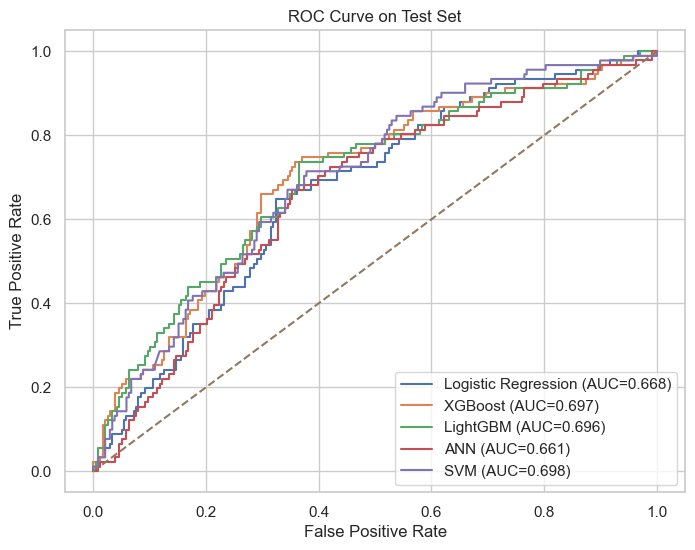

In [51]:
model_objects_for_test = {
    "Logistic Regression": (logit_final, X_test_scaled_final),
    "XGBoost": (xgb_final, X_test),
    "LightGBM": (lgbm_final, X_test),
    "ANN": (ann_final, X_test_scaled_final),
    "SVM": (svm_final, X_test_scaled_final)
}

plt.figure(figsize=(8, 6))

for model_name, (model_obj, X_input) in model_objects_for_test.items():
    _, y_prob = get_model_predictions(model_obj, X_input)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

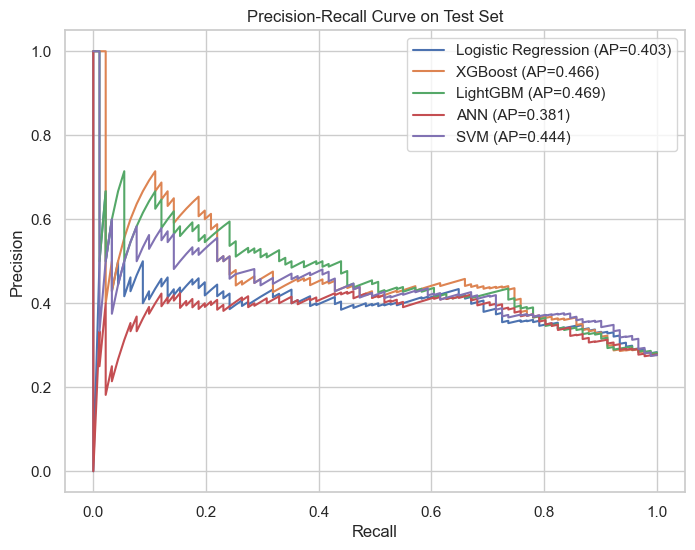

In [52]:
plt.figure(figsize=(8, 6))

for model_name, (model_obj, X_input) in model_objects_for_test.items():
    _, y_prob = get_model_predictions(model_obj, X_input)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{model_name} (AP={ap_score:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve on Test Set")
plt.legend()
plt.show()

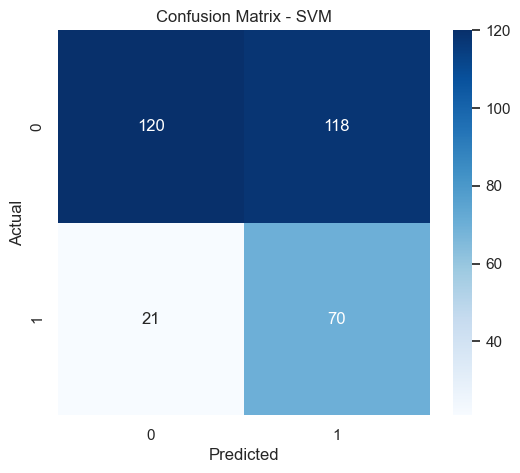

              precision    recall  f1-score   support

           0     0.8511    0.5042    0.6332       238
           1     0.3723    0.7692    0.5018        91

    accuracy                         0.5775       329
   macro avg     0.6117    0.6367    0.5675       329
weighted avg     0.7187    0.5775    0.5969       329



In [53]:
best_test_model_name = test_summary.loc[0, "Model"]
best_test_model, best_test_X = model_objects_for_test[best_test_model_name]

best_y_pred, best_y_prob = get_model_predictions(best_test_model, best_test_X)
cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_test_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, best_y_pred, digits=4))

In [54]:
if best_test_model_name == "Logistic Regression":
    coef_df = pd.DataFrame({
        "Feature": feature_cols,
        "Coefficient": best_test_model.coef_[0]
    }).sort_values("Coefficient", ascending=False)

    display(coef_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df, x="Coefficient", y="Feature")
    plt.title("Logistic Regression Coefficients")
    plt.show()
    
if best_test_model_name in ["XGBoost", "LightGBM"]:
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": best_test_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x="Importance", y="Feature")
    plt.title(f"Feature Importance - {best_test_model_name}")
    plt.show()

In [55]:
def tune_threshold(y_true, y_prob, metric="f1"):
    thresholds = np.arange(0.1, 0.91, 0.05)
    rows = []

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        rows.append({
            "threshold": th,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })

    result = pd.DataFrame(rows)
    best_row = result.sort_values(metric, ascending=False).iloc[0]
    return result, best_row

best_valid_model_name = validation_summary.loc[0, "Model"]

valid_model_objects = {
    "Logistic Regression": (logit_best_model, X_valid_scaled),
    "XGBoost": (xgb_best_model, X_valid),
    "LightGBM": (lgbm_best_model, X_valid),
    "ANN": (ann_best_model, X_valid_scaled),
    "SVM": (svm_best_model, X_valid_scaled)
}

model_obj, X_input = valid_model_objects[best_valid_model_name]
_, valid_prob = get_model_predictions(model_obj, X_input)

threshold_df, best_threshold_row = tune_threshold(y_valid, valid_prob, metric="f1")
display(threshold_df.sort_values("f1", ascending=False))
print("Best threshold:", best_threshold_row["threshold"])

,threshold,precision,recall,f1
5,0.35,0.428571,0.631579,0.510638
4,0.30,0.398810,0.705263,0.509506
6,0.40,0.447154,0.578947,0.504587
3,0.25,0.363636,0.715789,0.482270
7,0.45,0.456311,0.494737,0.474747
1,0.15,0.331933,0.831579,0.474474
2,0.20,0.344660,0.747368,0.471761
0,0.10,0.315412,0.926316,0.470588
8,0.50,0.508772,0.305263,0.381579
9,0.55,0.555556,0.105263,0.176991


Best threshold: 0.3500000000000001
